# 09b · Deconvolution results — review

Lightweight browser for the cell2location run (`03/09`, completed 2026-09-16 on the Tailscale peer).
Reads only the small local artifacts in `results/tables/deconvolution/` and
`results/figures/manuscript/deconv_*` — **no compute, no 4.8 GB h5ad needed**.

For the full pipeline + baked-in outputs see `09-microglia-deconvolution.executed.ipynb`.

**Read the caveats at the bottom before quoting any immune numbers.**

In [1]:
%matplotlib inline
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import image as mpimg

ROOT = Path.cwd()
while not (ROOT / 'results').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
TBL = ROOT / 'results' / 'tables' / 'deconvolution'
FIG = ROOT / 'results' / 'figures' / 'manuscript'

frac  = pd.read_csv(TBL / 'per_spot_fractions.csv', index_col=0)
comp  = pd.read_csv(TBL / 'region_treatment_composition.csv')
shift = pd.read_csv(TBL / 'myeloid_state_BRIvPBS_shift.tsv', sep='\t')

MYE = [c for c in frac.columns if c.startswith('MYE:')]
STRUCT = [c for c in frac.columns if not c.startswith('MYE:')]
# the myeloid states we actually trust (see caveats)
CREDIBLE = ['MYE:Microglia', 'MYE:CAM', 'MYE:MDM', 'MYE:Granulocyte']
print(f'{frac.shape[0]:,} spots x {frac.shape[1]} cell types')
print('structural:', STRUCT)
print('immune    :', MYE)

25,660 spots x 18 cell types
structural: ['Astrocytes', 'Ependymal', 'Neurons', 'Oligos', 'PeripheralGlia', 'Vascular']
immune    : ['MYE:CAM', 'MYE:CD4 Th17', 'MYE:CD8 TRM', 'MYE:Granulocyte', 'MYE:MAIT', 'MYE:MDM', 'MYE:Microglia', 'MYE:NK', 'MYE:Plamablasts', 'MYE:TEx', 'MYE:Treg', 'MYE:cDC1']


## 1 · Overall composition (all spots)

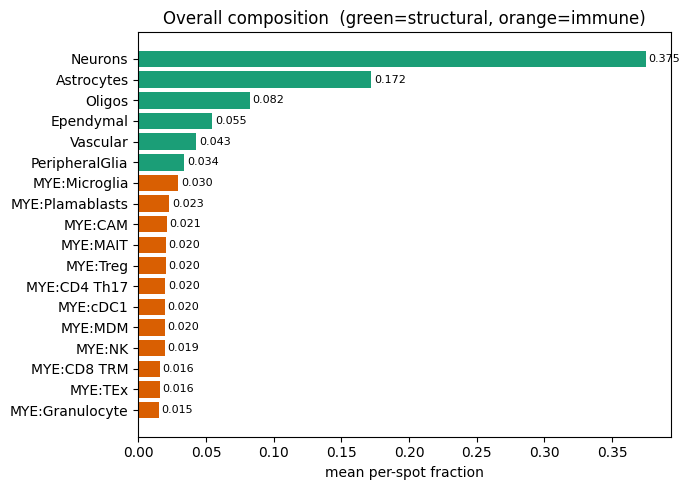

total immune  = 0.239  (INFLATED — see caveats)
total struct  = 0.761


In [2]:
mean = frac.mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,5))
colors = ['#d95f02' if c.startswith('MYE:') else '#1b9e77' for c in mean.index]
ax.barh(mean.index[::-1], mean.values[::-1], color=colors[::-1])
ax.set_xlabel('mean per-spot fraction')
ax.set_title('Overall composition  (green=structural, orange=immune)')
for i,v in enumerate(mean.values[::-1]):
    ax.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

print(f"total immune  = {frac[MYE].sum(axis=1).mean():.3f}  (INFLATED — see caveats)")
print(f"total struct  = {frac[STRUCT].sum(axis=1).mean():.3f}")

## 2 · Microglia & aggregate myeloid by region × treatment
The credible readouts. Note WT (untreated) vs the two injected conditions, and BRICHOS vs PBS.

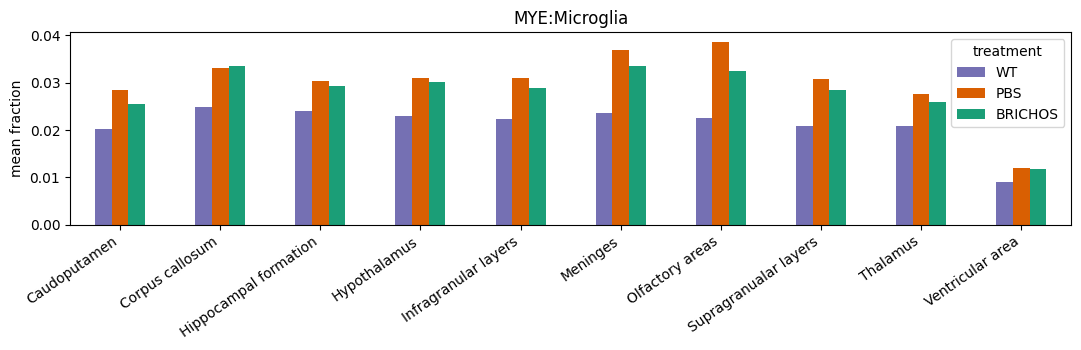

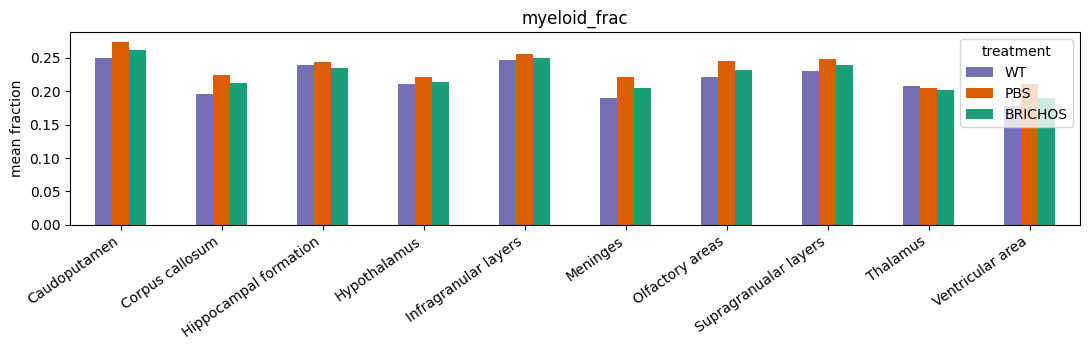

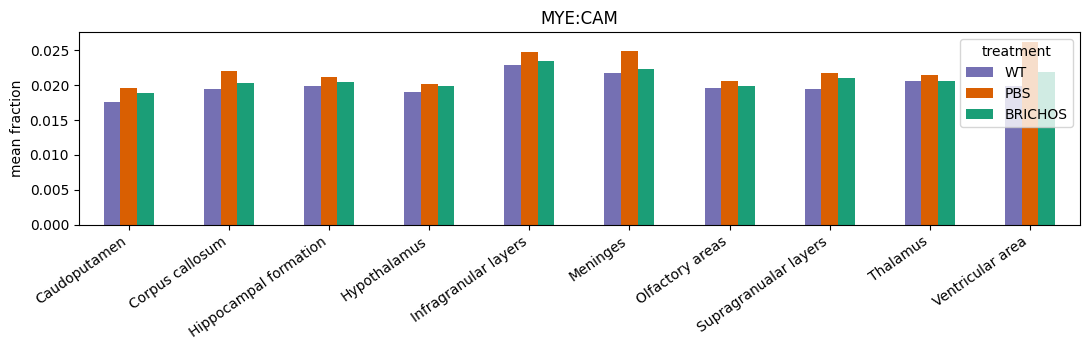

In [3]:
comp2 = comp.copy()
comp2['myeloid_frac'] = comp2[MYE].sum(axis=1)
order = ['WT','PBS','BRICHOS']
palette = {'WT':'#7570b3','PBS':'#d95f02','BRICHOS':'#1b9e77'}

for feat in ['MYE:Microglia','myeloid_frac','MYE:CAM']:
    piv = comp2.pivot(index='re_annotation_regions', columns='treatment', values=feat)[order]
    ax = piv.plot(kind='bar', figsize=(11,3.6), color=[palette[t] for t in order])
    ax.set_title(feat); ax.set_ylabel('mean fraction'); ax.set_xlabel('')
    plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

## 3 · BRICHOS − PBS shift (credible myeloid states)
Negative delta = BRICHOS lower than PBS. p-values are at the discrete floor (few replicates) → exploratory.

,region,state,mean_pbs,mean_bri,delta,mwu_p
42,Hippocampal formation,MYE:CAM,0.0334,0.0235,-0.0099,0.381
9,Ventricular area,MYE:CAM,0.0265,0.0220,-0.0045,0.095
77,Olfactory areas,MYE:Microglia,0.0377,0.0336,-0.0041,0.714
15,Meninges,MYE:Microglia,0.0370,0.0338,-0.0033,0.167
64,Hippocampal formation,MYE:Microglia,0.0278,0.0246,-0.0032,0.571
21,Caudoputamen,MYE:Microglia,0.0292,0.0261,-0.0031,0.167
1,Meninges,MYE:MDM,0.0221,0.0192,-0.0028,0.024
19,Supragranualar layers,MYE:Microglia,0.0308,0.0284,-0.0024,0.167
10,Meninges,MYE:CAM,0.0248,0.0225,-0.0023,0.095
51,Ventricular area,MYE:Granulocyte,0.0215,0.0192,-0.0022,0.548


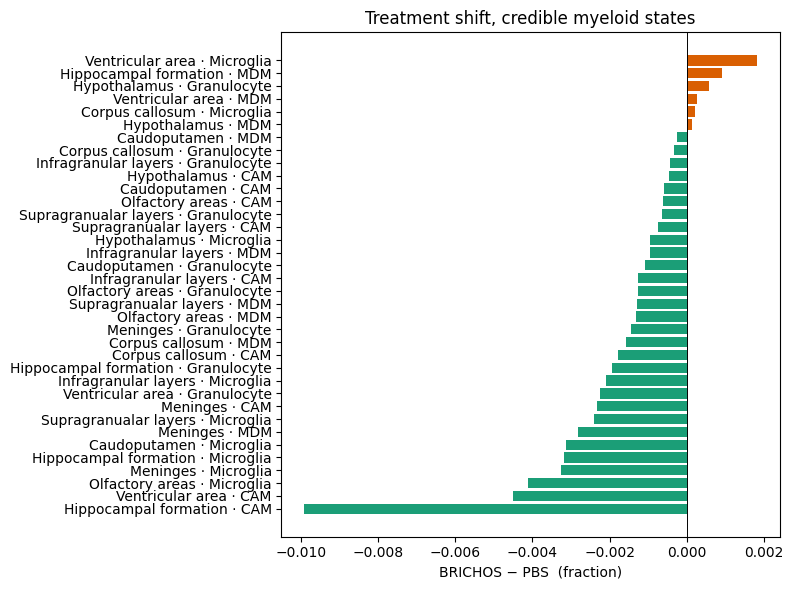

In [4]:
sub = shift[shift['state'].isin(CREDIBLE)].sort_values('delta')
disp = sub.assign(delta=sub['delta'].round(4), mwu_p=sub['mwu_p'].round(3))
display(disp[['region','state','mean_pbs','mean_bri','delta','mwu_p']].round(4))

fig, ax = plt.subplots(figsize=(8,6))
lab = (sub['region']+' · '+sub['state'].str.replace('MYE:',''))
ax.barh(lab, sub['delta'], color=np.where(sub['delta']<0,'#1b9e77','#d95f02'))
ax.axvline(0, color='k', lw=.7); ax.set_xlabel('BRICHOS − PBS  (fraction)')
ax.set_title('Treatment shift, credible myeloid states'); plt.tight_layout(); plt.show()

## 4 · Spatial maps (rendered PNGs)

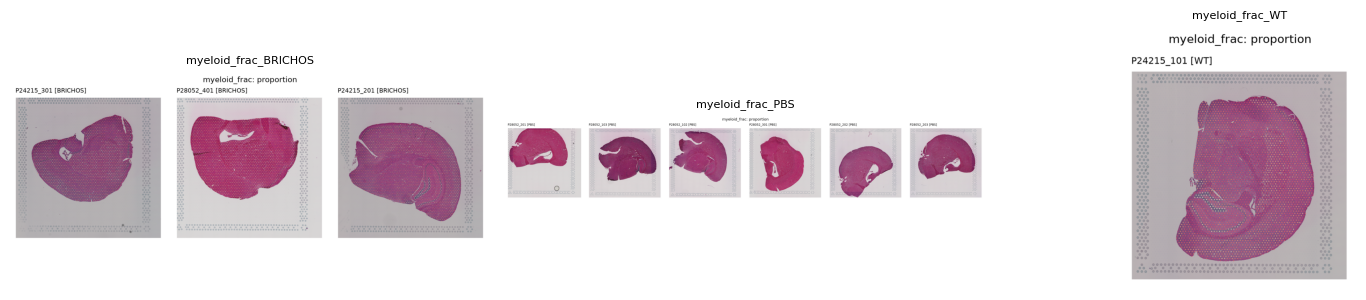

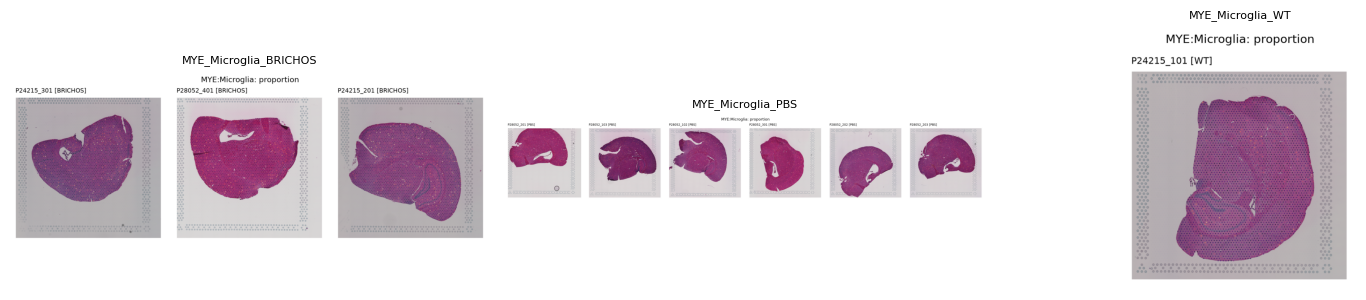

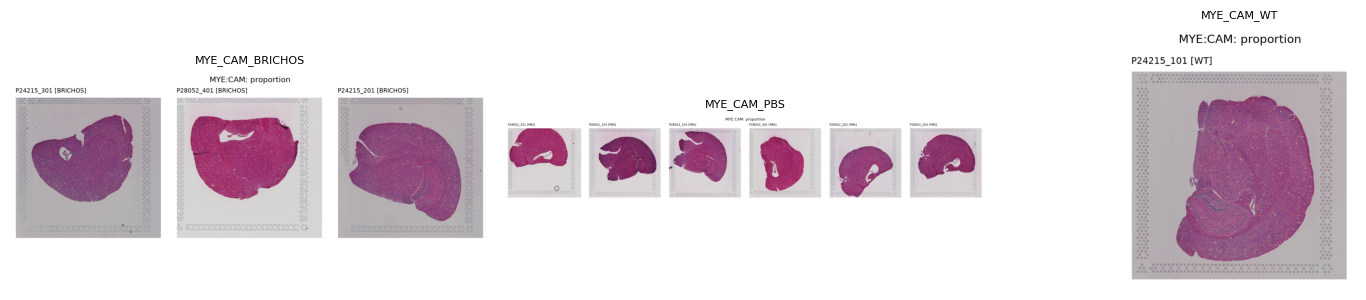

In [5]:
def show(pattern, ncol=3, w=15):
    files = sorted(FIG.glob(pattern))
    if not files:
        print('no files for', pattern); return
    nrow = int(np.ceil(len(files)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(w, w/ncol*nrow*0.62))
    for ax, f in zip(np.ravel(axes), files):
        ax.imshow(mpimg.imread(f)); ax.set_title(f.stem.replace('deconv_',''), fontsize=8); ax.axis('off')
    for ax in np.ravel(axes)[len(files):]: ax.axis('off')
    plt.tight_layout(); plt.show()

show('deconv_myeloid_frac_*.png')
show('deconv_MYE_Microglia_*.png')
show('deconv_MYE_CAM_*.png')

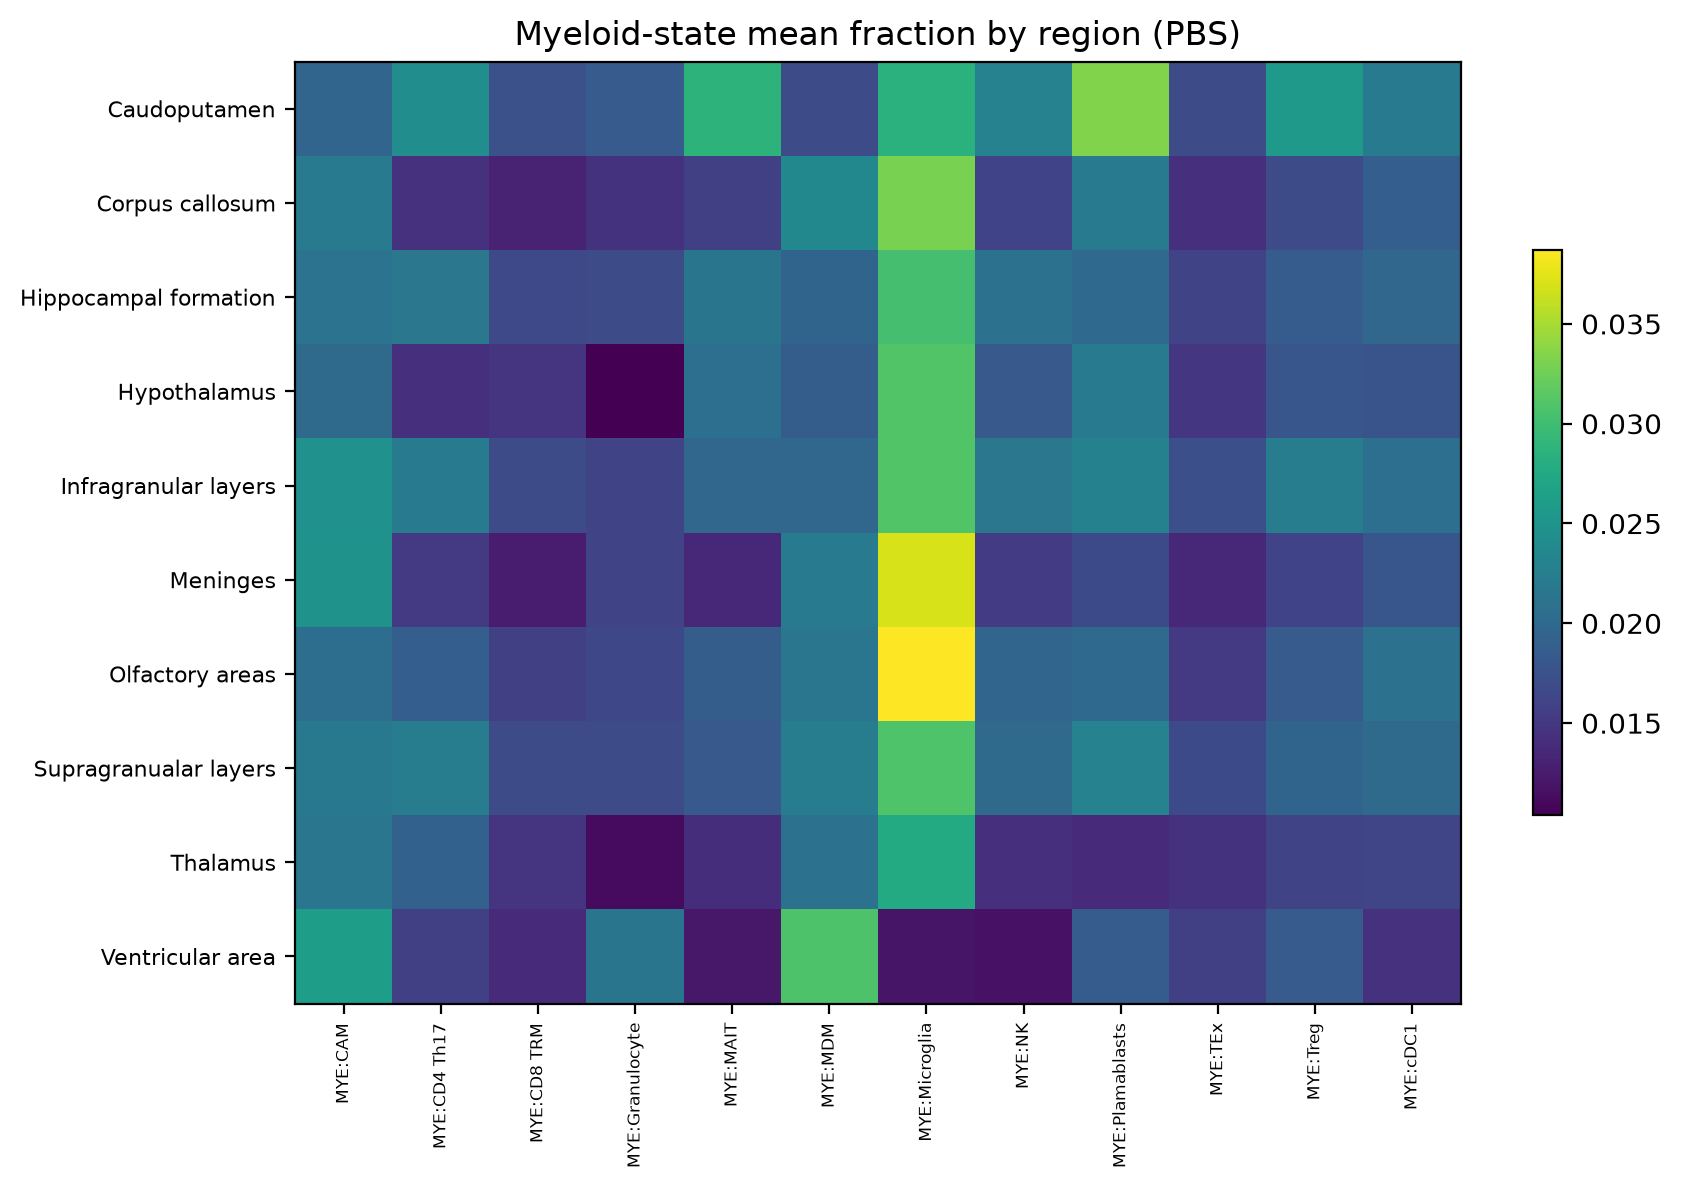

In [6]:
from IPython.display import Image
Image(str(FIG / 'deconv_myeloid_region_heatmap.png'))

## 5 · Caveats — read before quoting numbers

- **Total immune ≈ 24 %/spot is inflated.** cell2location spread mass across the 12 similar rare immune signatures. The adaptive/peripheral states (CD4 Th17, CD8 TRM, MAIT, NK, Treg, TEx, cDC1, Plasmablasts) sit at a flat ~1.5–2 % floor with little spatial structure → **signature bleed, not real resident cells**. Trust **Microglia + CAM** (and MDM/Granulocyte at interfaces) only.
- **p-values are at the discrete Mann-Whitney floor (0.0238)** → very few biological replicates. Exploratory; needs per-sample aggregation + FDR.
- **Biological signal (cautious, consistent):** injection raises microglia / lowers neurons (BRI & PBS > WT); **BRICHOS < PBS microglia across most regions** → partial normalization toward WT. Dovetails with the BA4_MIC-7 resilience result in `03/08`.

**To improve:** prune the reference to CNS-resident myeloid types (or collapse T/NK/B) and re-run; per-panel percentile scaling on spatial maps; per-sample stats with FDR; correlate per-spot Microglia/CAM props with the `03/08` MIC-7 score.